# What New Yorkers complain about, in plain SQL

A sample of **214,000 requests to New York's 311 service line** from 2023: what people report, how fast the city responds, and how complaints change with the hour and the season. Seven questions in SQL only, including **median and 90th-percentile response times** built from `ROW_NUMBER` and `COUNT() OVER` (SQLite has no percentile function), pivots with conditional aggregation and a *location quotient* that shows what each borough is unusually known for.

**Data:** [311 Service Requests](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9) from NYC Open Data. Run `python build_db.py` once to download the sample (about 30 MB) into a SQLite database, then point `NYC311_DB` at that file.

**Reading the data.** To keep the download small, only requests created on the **1st and 15th of each month** are included, so counts are for 24 sampled days, not the whole year. Request that were closed before they were created (a data-entry error in 229 rows) are left out of the response-time questions.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("NYC311_DB", "nyc311.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,requests,213894


## 1. What do people complain about?

A plain `GROUP BY` with `SUM(COUNT(*)) OVER ()` for the share of all requests.

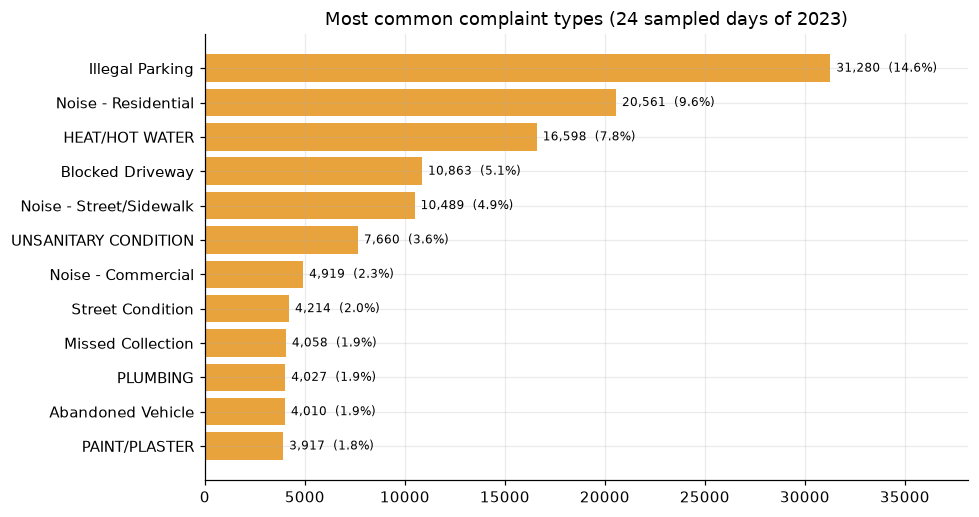

In [3]:
top = q("""
SELECT complaint_type,
       COUNT(*)                                           AS requests,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct
FROM requests
GROUP BY complaint_type
ORDER BY requests DESC
LIMIT 12
""")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(top.complaint_type[::-1], top.requests[::-1], color=AMBER)
for y, (v, s) in enumerate(zip(top.requests[::-1], top.share_pct[::-1])):
    ax.text(v + 300, y, f"{v:,}  ({s}%)", va="center", fontsize=8)
ax.set_xlim(0, top.requests.max() * 1.22)
ax.set_title("Most common complaint types (24 sampled days of 2023)")
fig.tight_layout()
plt.show()

## 2. How do the boroughs compare?

`ROW_NUMBER() OVER (PARTITION BY borough ORDER BY n DESC)` picks each borough's most common complaint.

In [4]:
boroughs = q("""
WITH borough_type AS (
    SELECT borough, complaint_type, COUNT(*) AS n
    FROM requests
    WHERE borough <> 'Unspecified'
    GROUP BY borough, complaint_type
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY borough ORDER BY n DESC) AS rn,
           SUM(n)       OVER (PARTITION BY borough)                 AS total,
           SUM(n)       OVER ()                                     AS grand_total
    FROM borough_type
)
SELECT borough,
       total                                   AS requests,
       ROUND(100.0 * total / grand_total, 1)   AS share_of_city_pct,
       complaint_type                          AS most_common_complaint,
       ROUND(100.0 * n / total, 1)             AS its_share_pct
FROM ranked
WHERE rn = 1
ORDER BY requests DESC
""")

boroughs

,borough,requests,share_of_city_pct,most_common_complaint,its_share_pct
0,Brooklyn,65415,31.0,Illegal Parking,17.6
1,Queens,50702,24.0,Illegal Parking,18.1
2,Manhattan,45302,21.4,Illegal Parking,9.5
3,Bronx,41711,19.7,HEAT/HOT WATER,14.3
4,Staten Island,8141,3.9,Illegal Parking,10.1


## 3. Which agencies respond fastest?

Response time is `closed_date - created_date`. SQLite has no `MEDIAN` or `PERCENTILE`, so `ROW_NUMBER()` orders each agency's requests by duration and `COUNT(*) OVER` gives the group size: the row half-way down is the median, the row 90% of the way down is the 90th percentile.

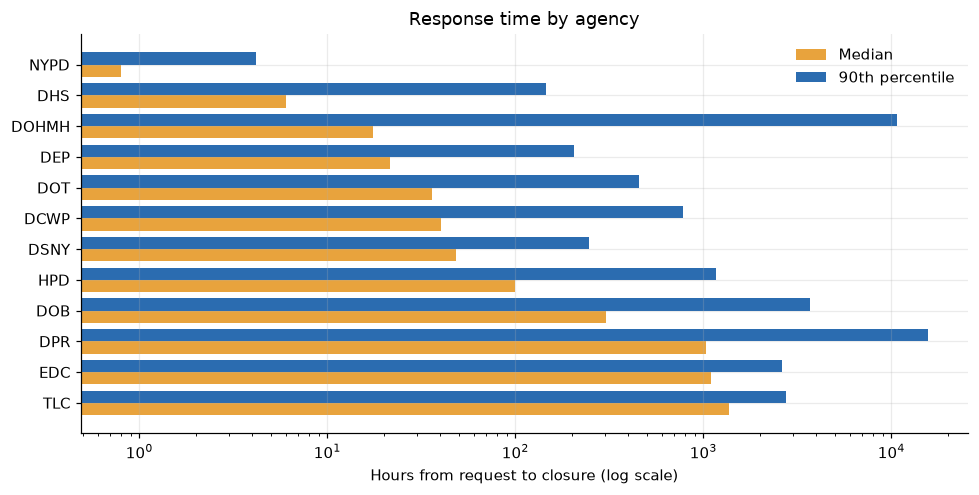

,agency,closed_requests,median_hours,p90_hours
0,NYPD,93226,0.8,4.2
1,DHS,1681,6.0,145.0
2,DOHMH,5037,17.6,10707.0
3,DEP,10854,21.6,206.3
4,DOT,12279,36.0,455.5
5,DCWP,1193,40.4,780.5
6,DSNY,19598,48.6,247.7
7,HPD,46749,99.9,1164.0
8,DOB,6536,302.1,3702.4
9,DPR,7375,1028.6,15618.4


In [5]:
response = q("""
WITH durations AS (
    SELECT agency,
           (julianday(closed_date) - julianday(created_date)) * 24 AS hours
    FROM requests
    WHERE closed_date IS NOT NULL AND closed_date >= created_date
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY agency ORDER BY hours) AS rn,
           COUNT(*)     OVER (PARTITION BY agency)                AS n
    FROM durations
)
SELECT agency,
       MAX(n)                                                              AS closed_requests,
       ROUND(MAX(CASE WHEN rn = CAST(n * 0.5 AS INT) + 1 THEN hours END), 1) AS median_hours,
       ROUND(MAX(CASE WHEN rn = CAST(n * 0.9 AS INT) + 1 THEN hours END), 1) AS p90_hours
FROM ranked
GROUP BY agency
HAVING closed_requests >= 1000
ORDER BY median_hours
""")

plot_df = response.sort_values("median_hours")
fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(plot_df))
ax.barh(y + 0.2, plot_df.median_hours, height=0.4, color=AMBER, label="Median")
ax.barh(y - 0.2, plot_df.p90_hours, height=0.4, color=BLUE, label="90th percentile")
ax.set_yticks(y, plot_df.agency)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Hours from request to closure (log scale)")
ax.set_title("Response time by agency")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
response

## 4. Which complaints take longest to resolve?

The same percentile trick, now per complaint type (only types with at least 400 closed requests), reported in days.

In [6]:
slow = q("""
WITH durations AS (
    SELECT complaint_type,
           julianday(closed_date) - julianday(created_date) AS days
    FROM requests
    WHERE closed_date IS NOT NULL AND closed_date >= created_date
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY complaint_type ORDER BY days) AS rn,
           COUNT(*)     OVER (PARTITION BY complaint_type)               AS n
    FROM durations
)
SELECT complaint_type,
       MAX(n)                                                            AS closed_requests,
       ROUND(MAX(CASE WHEN rn = CAST(n * 0.5 AS INT) + 1 THEN days END), 1) AS median_days,
       ROUND(MAX(CASE WHEN rn = CAST(n * 0.9 AS INT) + 1 THEN days END), 1) AS p90_days
FROM ranked
GROUP BY complaint_type
HAVING closed_requests >= 400
ORDER BY median_days DESC
LIMIT 10
""")

slow

,complaint_type,closed_requests,median_days,p90_days
0,New Tree Request,1328,559.0,743.0
1,Food Establishment,758,338.3,488.1
2,Overgrown Tree/Branches,1165,111.0,660.3
3,Taxi Complaint,407,84.0,138.2
4,Building/Use,1192,64.8,432.5
5,For Hire Vehicle Complaint,1318,63.1,117.2
6,Root/Sewer/Sidewalk Condition,542,62.3,577.0
7,Dead/Dying Tree,559,53.9,605.0
8,Noise - Helicopter,2636,45.9,109.5
9,Elevator,1254,33.5,72.7


## 5. When do different complaints come in?

For the four most common complaint types, each hour's count is divided by the type's daily total (`SUM(n) OVER (PARTITION BY type)`), giving a comparable 24-hour profile. Complaints logged at exactly midnight are excluded, because many agencies stamp 00:00:00 when the real time is unknown.

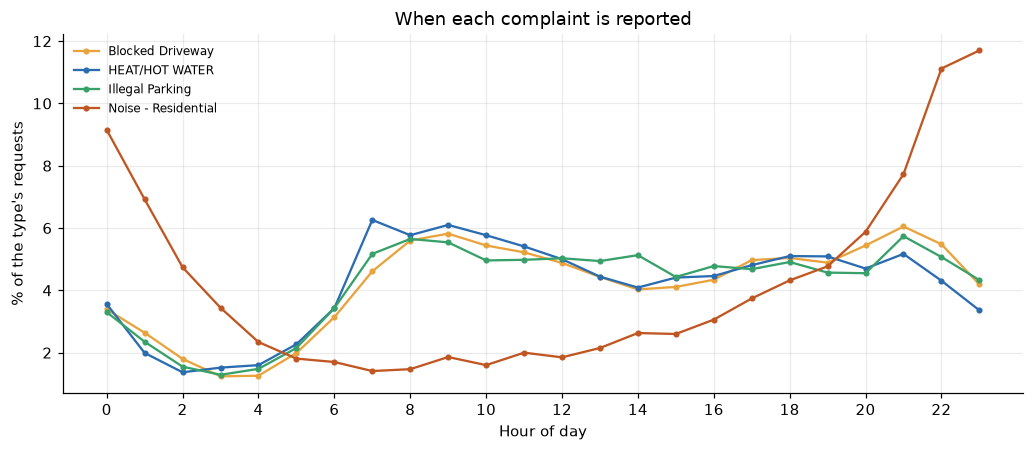

In [7]:
hourly = q("""
WITH top_types AS (
    SELECT complaint_type FROM requests GROUP BY complaint_type ORDER BY COUNT(*) DESC LIMIT 4
),
hourly AS (
    SELECT complaint_type,
           CAST(strftime('%H', created_date) AS INT) AS hour,
           COUNT(*)                                  AS n
    FROM requests
    WHERE complaint_type IN (SELECT complaint_type FROM top_types)
      AND strftime('%H:%M:%S', created_date) <> '00:00:00'
    GROUP BY complaint_type, hour
)
SELECT complaint_type, hour, n,
       ROUND(100.0 * n / SUM(n) OVER (PARTITION BY complaint_type), 2) AS share_of_day_pct
FROM hourly
ORDER BY complaint_type, hour
""")

wide = hourly.pivot(index="hour", columns="complaint_type", values="share_of_day_pct")
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for col, color in zip(wide.columns, [AMBER, BLUE, "#38a169", "#c05621"]):
    ax.plot(wide.index, wide[col], marker="o", ms=3, label=col, color=color)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_ylabel("% of the type's requests")
ax.set_title("When each complaint is reported")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 6. Which complaints follow the seasons?

Conditional aggregation pivots the months into columns directly in SQL. Counts are divided by the two sampled days per month, so they read as complaints per sampled day. December has only its 1st and 15th, like the rest.

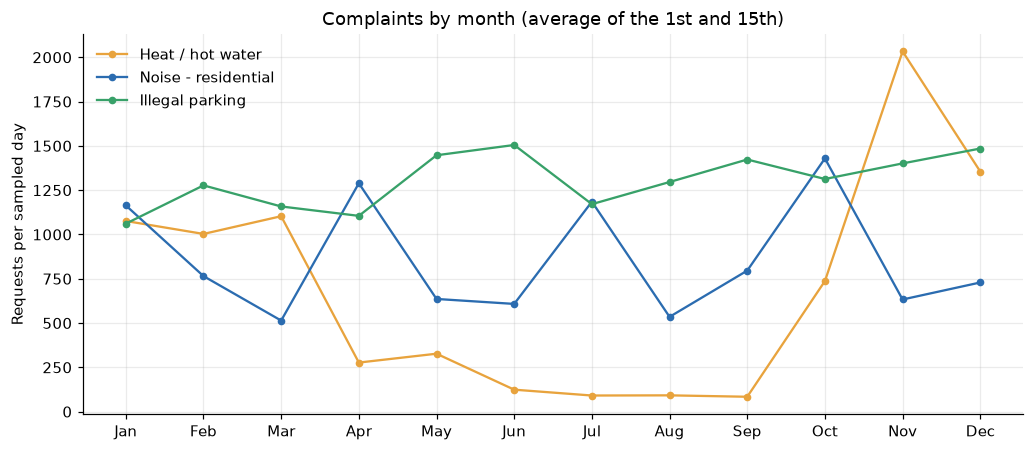

,month,heat_hot_water,noise_residential,illegal_parking,water_plumbing,all_requests
0,01,1076.0,1164.0,1061.0,133.0,6522.0
1,02,1003.0,765.0,1277.0,283.0,8589.0
2,03,1103.0,514.0,1158.0,258.0,8082.0
3,04,277.0,1289.0,1105.0,130.0,7370.0
4,05,327.0,636.0,1447.0,486.0,10161.0
5,06,124.0,608.0,1505.0,289.0,9117.0
6,07,91.0,1185.0,1171.0,300.0,8157.0
7,08,92.0,535.0,1296.0,420.0,9559.0
8,09,84.0,796.0,1423.0,240.0,9199.0
9,10,737.0,1429.0,1313.0,349.0,9805.0


In [8]:
season = q("""
SELECT strftime('%m', created_date)                                          AS month,
       ROUND(SUM(complaint_type = 'HEAT/HOT WATER')        / 2.0)           AS heat_hot_water,
       ROUND(SUM(complaint_type = 'Noise - Residential')   / 2.0)           AS noise_residential,
       ROUND(SUM(complaint_type = 'Illegal Parking')       / 2.0)           AS illegal_parking,
       ROUND(SUM(complaint_type LIKE 'Water%'
              OR complaint_type = 'Plumbing')              / 2.0)           AS water_plumbing,
       ROUND(COUNT(*) / 2.0)                                                AS all_requests
FROM requests
GROUP BY month
ORDER BY month
""")

fig, ax = plt.subplots(figsize=(9.5, 4.2))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for col, color, label in [("heat_hot_water", AMBER, "Heat / hot water"),
                          ("noise_residential", BLUE, "Noise - residential"),
                          ("illegal_parking", "#38a169", "Illegal parking")]:
    ax.plot(months, season[col], marker="o", ms=4, label=label, color=color)
ax.set_ylabel("Requests per sampled day")
ax.set_title("Complaints by month (average of the 1st and 15th)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
season

## 7. What is each borough unusually known for?

A **location quotient**: the share of a borough's requests that are of a given type, divided by that type's share across the whole city. A value of 2 means the borough reports it twice as often as the city average. `ROW_NUMBER` keeps the top two per borough among types with at least 150 requests there.

In [9]:
quotient = q("""
WITH borough_type AS (
    SELECT borough, complaint_type, COUNT(*) AS n
    FROM requests
    WHERE borough <> 'Unspecified'
    GROUP BY borough, complaint_type
),
shares AS (
    SELECT *,
           1.0 * n / SUM(n) OVER (PARTITION BY borough)         AS borough_share,
           1.0 * SUM(n) OVER (PARTITION BY complaint_type)
               / SUM(n) OVER ()                                 AS city_share
    FROM borough_type
),
ranked AS (
    SELECT *, borough_share / city_share AS quotient,
           ROW_NUMBER() OVER (PARTITION BY borough ORDER BY borough_share / city_share DESC) AS rn
    FROM shares
    WHERE n >= 150
)
SELECT borough, complaint_type, n AS requests,
       ROUND(100.0 * borough_share, 1) AS borough_share_pct,
       ROUND(100.0 * city_share, 1)    AS city_share_pct,
       ROUND(quotient, 1)              AS location_quotient
FROM ranked
WHERE rn <= 2
ORDER BY borough, location_quotient DESC
""")

quotient

,borough,complaint_type,requests,borough_share_pct,city_share_pct,location_quotient
0,Bronx,Elevator,529,1.3,0.6,2.1
1,Bronx,APPLIANCE,548,1.3,0.7,1.9
2,Brooklyn,Street Sweeping Complaint,285,0.4,0.2,1.9
3,Brooklyn,Illegal Posting,159,0.2,0.1,1.7
4,Manhattan,Bike/Roller/Skate Chronic,338,0.7,0.2,3.9
5,Manhattan,Lost Property,325,0.7,0.2,3.6
6,Queens,Drug Activity,806,1.6,0.5,3.3
7,Queens,Dead/Dying Tree,318,0.6,0.3,2.0
8,Staten Island,Electronics Waste Appointment,555,6.8,0.3,26.0
9,Staten Island,Missed Collection,497,6.1,1.9,3.3


## What the queries say

- **Parking is the number one complaint.** Illegal parking is 14.6% of all requests, ahead of residential noise (9.6%) and heat or hot water (7.8%). It is the top complaint in four of the five boroughs; in the Bronx, heat and hot water leads (14.3% of its requests). Brooklyn files the most requests (31% of the city's), then Queens (24%), Manhattan (21%), the Bronx (20%) and Staten Island (4%).
- **Response times span three orders of magnitude.** The NYPD closes a request in a median of 0.8 hours. DHS takes 6 hours, DEP about 22, HPD about 100 (four days), the Department of Buildings 302 hours (about 13 days), and Parks and the Taxi and Limousine Commission about 43 and 57 days. The tails are far longer than the medians: for the health department the 90th percentile is 10,700 hours, about 450 days. Closing time reflects each agency's workflow as well as how fast the problem was fixed.
- **Some complaints take more than a year.** New tree requests have a median of 559 days to close and food-establishment complaints 338 days, both of which involve scheduling work or inspections rather than a quick fix. Overgrown trees take a median of 111 days.
- **Each complaint has its own clock.** Residential noise peaks at 11 p.m. (11.7% of all its requests arrive in that hour alone), heating complaints peak at 7 a.m. (6.3%), and illegal parking and blocked driveways both peak at 9 p.m.
- **Heat and hot water is the clearest seasonal signal.** It averages 84-92 requests per sampled day in summer and 2,033 in November, about 22 times more. Residential noise does not show a clean seasonal curve here, but with only two sampled days per month, single days like a holiday or a hot weekend move it a lot.
- **Boroughs have a character.** Compared with the citywide average, Staten Island files electronics-waste appointment requests 26 times as often, Manhattan files bike and skate complaints 3.9 times and lost property 3.6 times as often, Queens files drug-activity complaints 3.3 times as often, and the Bronx files elevator complaints twice as often.

**Limits:** the data is a sample of the 1st and 15th of each month, so absolute counts are for 24 days, not the year; 229 requests closed before they were opened are excluded from the timing questions; and "closed" is the agency's status, not proof the issue was resolved.

**Techniques covered:** `ROW_NUMBER` and `COUNT() OVER` to build medians and percentiles, `SUM() OVER` shares, conditional aggregation pivots and a location quotient with a `ROW_NUMBER` filter.
